# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AC05743

Name: Mohammad Uzair

Email: 2025ac05743@wilp.bits-pilani.ac.in

Date: 08-Aug-2026

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

In [2]:
# Deep learning framework: Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from PIL import Image

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [3]:
# --- Colab / GPU check ---
# Recommended: Runtime -> Change runtime type -> T4 GPU (TensorFlow uses it automatically).
print("Num GPUs available:", len(tf.config.list_physical_devices('GPU')))
print("Devices:", [d.device_type for d in tf.config.list_physical_devices()])

Num GPUs available: 1
Devices: ['CPU', 'GPU']


### 1.1 Dataset Selection and Loading

**Dataset:** Cats vs Dogs (2 classes), downloaded directly from Microsoft's public *Kaggle Cats and Dogs* dataset via `keras.utils.get_file` - a public source, so no data files are bundled with the notebook. We use a balanced subset of **2000 valid images per class (4000 total)**, skip the few corrupt files, and split **85/15** into train/test. Images are resized to 160x160 with a `tf.data` pipeline. _Tuned for a Google Colab GPU runtime (Runtime -> Change runtime type -> T4 GPU)._

_Note: `tensorflow_datasets` is intentionally avoided because Colab currently has a protobuf gencode/runtime conflict that breaks its import._

In [4]:
# ---- Dataset loading: Cats vs Dogs (Microsoft public dataset, no tfds) ----
# tensorflow_datasets is avoided because Colab currently has a protobuf gencode/runtime
# conflict that breaks its import. We download the same underlying dataset directly.
import zipfile, glob, random, pathlib
random.seed(42)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
PER_CLASS = 2000           # balanced subset per class (>= 500 required)
AUTOTUNE = tf.data.AUTOTUNE

_url = ("https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/"
        "kagglecatsanddogs_5340.zip")
_zip = keras.utils.get_file("kagglecatsanddogs_5340.zip", origin=_url)   # downloads & caches
_dst = pathlib.Path(_zip).parent / "cvd_petimages"
if not _dst.exists():
    with zipfile.ZipFile(_zip) as z:
        z.extractall(_dst)
base = _dst / "PetImages"                       # contains Cat/ and Dog/

folder_for = {"cats": "Cat", "dogs": "Dog"}
class_names = ["cats", "dogs"]                  # label index: cats=0, dogs=1
num_classes = len(class_names)

def _valid_jpeg(path):
    # a handful of files in this dataset are truncated / not real JPEGs -> skip them
    try:
        img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
        return int(tf.shape(img)[0]) > 0
    except Exception:
        return False

# collect a balanced subset of VALID images per class
all_paths, all_labels = [], []
per_class_counts = {}
for idx, cls in enumerate(class_names):
    files = sorted(glob.glob(str(base / folder_for[cls] / "*.jpg")))
    random.shuffle(files)
    kept = []
    for f in files:
        if _valid_jpeg(f):
            kept.append(f)
        if len(kept) >= PER_CLASS:
            break
    per_class_counts[cls] = len(kept)
    all_paths += kept
    all_labels += [idx] * len(kept)

# shuffle, then 85/15 train/test split
combined = list(zip(all_paths, all_labels))
random.shuffle(combined)
all_paths, all_labels = [list(t) for t in zip(*combined)]

n_samples = len(all_paths)
split = int(0.85 * n_samples)
train_paths, train_labels = all_paths[:split], all_labels[:split]
test_paths,  test_labels  = all_paths[split:], all_labels[split:]
train_count, test_count = len(train_paths), len(test_paths)

def _decode(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, IMG_SIZE)        # float32 in [0, 255]
    return img, label

def _make_ds(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    return ds.cache().prefetch(AUTOTUNE)

train_ds = _make_ds(train_paths, train_labels, True)
test_ds  = _make_ds(test_paths,  test_labels,  False)   # no shuffle -> labels stay aligned

print("Classes:", class_names)
print("Per-class images used:", per_class_counts)
print(f"Total: {n_samples} | Train: {train_count} | Test: {test_count}")

824887076/824887076 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Classes: ['cats', 'dogs']
Per-class images used: {'cats': 2000, 'dogs': 2000}
Total: 4000 | Train: 3400 | Test: 600


In [5]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Cats vs Dogs"
dataset_source = "Microsoft Kaggle Cats vs Dogs (kagglecatsanddogs_5340.zip via keras.utils.get_file)"
n_samples = int(n_samples)                     # total valid images used
n_classes = num_classes                        # 2
_mn, _mx = min(per_class_counts.values()), max(per_class_counts.values())
_avg = sum(per_class_counts.values()) / n_classes
samples_per_class = f"min: {_mn}, max: {_mx}, avg: {_avg:.0f}"
image_shape = [IMG_SIZE[0], IMG_SIZE[1], 3]   # [height, width, channels]
problem_type = "classification"

In [6]:
# Primary metric selection
primary_metric = "accuracy"
metric_justification = (
    "The dataset is perfectly balanced (equal numbers of cats and dogs) and both error "
    "types are equally important, so accuracy is a fair and representative measure of "
    "overall classification performance."
)

In [7]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Cats vs Dogs
Source: Microsoft Kaggle Cats vs Dogs (kagglecatsanddogs_5340.zip via keras.utils.get_file)
Total Samples: 4000
Number of Classes: 2
Samples per Class: min: 2000, max: 2000, avg: 2000
Image Shape: [160, 160, 3]
Primary Metric: accuracy
Metric Justification: The dataset is perfectly balanced (equal numbers of cats and dogs) and both error types are equally important, so accuracy is a fair and representative measure of overall classification performance.


### 1.2 Data Exploration and Visualization

- TODO: Show sample images from each class
- TODO: Plot class distribution
- TODO: Display image statistics

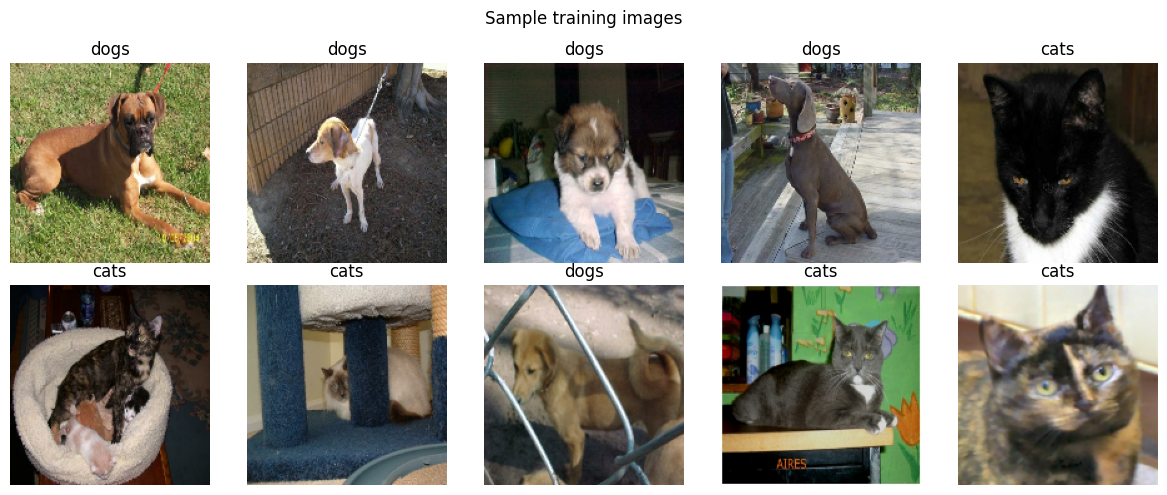

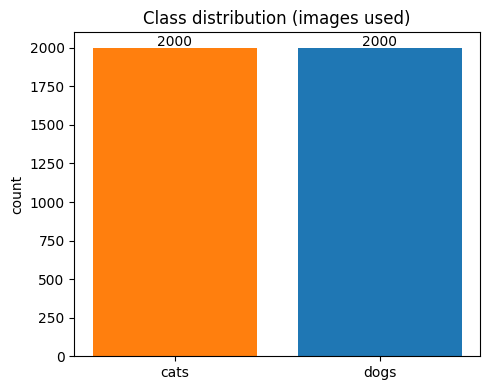

Image tensor shape (H, W, C): (160, 160, 3) | pixel range [0, 255] before per-model normalization


In [8]:
# ---- 1.2 EDA: sample images + class distribution ----
plt.figure(figsize=(12, 5))
for images, labels in train_ds.take(1):
    for i in range(min(len(images), 10)):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 4))
plt.bar(list(per_class_counts.keys()), list(per_class_counts.values()),
        color=["tab:orange", "tab:blue"])
plt.title("Class distribution (images used)"); plt.ylabel("count")
for i, v in enumerate(per_class_counts.values()):
    plt.text(i, v + 10, str(v), ha="center")
plt.tight_layout(); plt.show()

print("Image tensor shape (H, W, C):", tuple(image_shape),
      "| pixel range [0, 255] before per-model normalization")

### 1.3 Data Preprocessing
- TODO: Resize images to consistent size
- TODO: Normalize pixel values
- TODO: Split into train/test (90/10 or 85/15)

In [9]:
# REQUIRED: Document your split
train_test_ratio = "85/15"
train_samples = train_count
test_samples = test_count

In [10]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 85/15
Training Samples: 3400
Test Samples: 600


### 2.1 Custom CNN Architecture Design
- TODO: Define your CNN architecture
- TODO: Ensure Global Average Pooling is included (MANDATORY)
- TODO: Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [11]:
def build_custom_cnn(input_shape, n_classes):
    """
    Custom CNN: 4 Conv2D blocks (Conv-BN-ReLU) with MaxPooling, then
    Global Average Pooling (MANDATORY) -> Softmax output.
    GAP replaces a dense top head, cutting parameters and overfitting.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1.0 / 255),                      # normalize pixels to [0, 1]

        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),

        layers.GlobalAveragePooling2D(),                  # Global Average Pooling (GAP)
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ], name="custom_cnn")
    return model

In [12]:
# Create model instance
custom_cnn = build_custom_cnn(tuple(image_shape), n_classes)
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,850 (1.49 MB)

 Trainable params: 389,890 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# Compile model
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # integer labels (0=cats, 1=dogs)
    metrics=["accuracy"],
)
print("Custom CNN compiled. Total parameters:", f"{custom_cnn.count_params():,}")

Custom CNN compiled. Total parameters: 390,850


### 2.2 Train Custom CNN

In [14]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [15]:
# Train custom CNN
CUSTOM_EPOCHS = 40
custom_cnn_history = custom_cnn.fit(train_ds, epochs=CUSTOM_EPOCHS, verbose=2)

Epoch 1/40
107/107 - 19s - 175ms/step - accuracy: 0.6032 - loss: 0.6968
Epoch 2/40
107/107 - 4s - 33ms/step - accuracy: 0.6568 - loss: 0.6314
Epoch 3/40
107/107 - 4s - 34ms/step - accuracy: 0.6588 - loss: 0.6172
Epoch 4/40
107/107 - 3s - 32ms/step - accuracy: 0.6779 - loss: 0.6001
Epoch 5/40
107/107 - 3s - 32ms/step - accuracy: 0.7012 - loss: 0.5767
Epoch 6/40
107/107 - 4s - 34ms/step - accuracy: 0.7147 - loss: 0.5596
Epoch 7/40
107/107 - 5s - 47ms/step - accuracy: 0.7291 - loss: 0.5459
Epoch 8/40
107/107 - 3s - 33ms/step - accuracy: 0.7400 - loss: 0.5357
Epoch 9/40
107/107 - 4s - 33ms/step - accuracy: 0.7400 - loss: 0.5228
Epoch 10/40
107/107 - 4s - 33ms/step - accuracy: 0.7526 - loss: 0.5124
Epoch 11/40
107/107 - 4s - 33ms/step - accuracy: 0.7718 - loss: 0.4948
Epoch 12/40
107/107 - 4s - 33ms/step - accuracy: 0.7835 - loss: 0.4816
Epoch 13/40
107/107 - 4s - 34ms/step - accuracy: 0.7906 - loss: 0.4598
Epoch 14/40
107/107 - 5s - 47ms/step - accuracy: 0.8062 - loss: 0.4456
Epoch 15/40
1

In [16]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [17]:
# REQUIRED: Track initial and final loss (from training history)
custom_cnn_initial_loss = float(custom_cnn_history.history["loss"][0])
custom_cnn_final_loss = float(custom_cnn_history.history["loss"][-1])
_red = (custom_cnn_initial_loss - custom_cnn_final_loss) / custom_cnn_initial_loss * 100
print(f"Initial loss: {custom_cnn_initial_loss:.4f} | Final loss: {custom_cnn_final_loss:.4f} | Reduction: {_red:.1f}%")

Initial loss: 0.6968 | Final loss: 0.1497 | Reduction: 78.5%


In [18]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 166.44 seconds
Initial Loss: 0.6968
Final Loss: 0.1497


In [19]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [20]:
# Predictions on the test set (single pass keeps labels and predictions aligned)
y_test, y_prob = [], []
for xb, yb in test_ds:
    y_test.append(yb.numpy())
    y_prob.append(custom_cnn.predict(xb, verbose=0))
y_test = np.concatenate(y_test)
custom_cnn_pred = np.argmax(np.concatenate(y_prob), axis=1)

# REQUIRED: Calculate all 4 metrics (macro-averaged)
custom_cnn_accuracy = float(accuracy_score(y_test, custom_cnn_pred))
custom_cnn_precision = float(precision_score(y_test, custom_cnn_pred, average="macro"))
custom_cnn_recall = float(recall_score(y_test, custom_cnn_pred, average="macro"))
custom_cnn_f1 = float(f1_score(y_test, custom_cnn_pred, average="macro"))

In [21]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.7667
Precision: 0.7949
Recall:    0.7774
F1-Score:  0.7648


### 2.4 Visualize Custom CNN Results
- TODO: Plot training loss curve
- TODO: Plot confusion matrix
- TODO: Show sample predictions

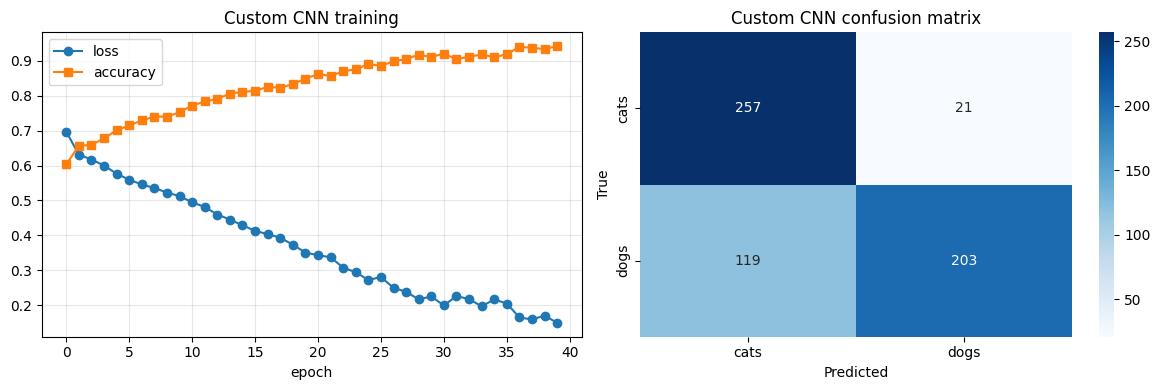

              precision    recall  f1-score   support

        cats       0.68      0.92      0.79       278
        dogs       0.91      0.63      0.74       322

    accuracy                           0.77       600
   macro avg       0.79      0.78      0.76       600
weighted avg       0.80      0.77      0.76       600



In [22]:
# ---- 2.4 Custom CNN: training curve + confusion matrix ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(custom_cnn_history.history["loss"], "o-", label="loss")
ax[0].plot(custom_cnn_history.history["accuracy"], "s-", label="accuracy")
ax[0].set_xlabel("epoch"); ax[0].set_title("Custom CNN training"); ax[0].legend(); ax[0].grid(alpha=.3)

cm = confusion_matrix(y_test, custom_cnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True"); ax[1].set_title("Custom CNN confusion matrix")
plt.tight_layout(); plt.show()

print(classification_report(y_test, custom_cnn_pred, target_names=class_names))

### 3.1 Load Pre-trained Model and Modify Architecture

In [23]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [24]:
# Choose pre-trained model
pretrained_model_name = "ResNet50"

In [25]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Transfer learning: frozen ResNet50 (ImageNet) feature extractor ->
    Global Average Pooling (MANDATORY) -> custom Dense (softmax) head.
    """
    base_model = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False               # freeze base layers (feature extractor)

    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(resnet_preprocess, name="resnet_preprocess")(inputs)  # ResNet preprocessing
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)     # Global Average Pooling (GAP)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="resnet50_transfer")
    return model

In [26]:
# Create transfer learning model
transfer_model = build_transfer_learning_model(pretrained_model_name, tuple(image_shape), n_classes)

# Compile
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
# REQUIRED: Count layers and parameters
base_model = next(l for l in transfer_model.layers if isinstance(l, keras.Model))  # nested ResNet50
frozen_layers = sum(1 for l in base_model.layers if not l.trainable)      # frozen base layers
trainable_layers = sum(1 for l in transfer_model.layers if l.trainable and l.count_params() > 0)
total_parameters = int(transfer_model.count_params())
trainable_parameters = int(sum(int(np.prod(w.shape)) for w in transfer_model.trainable_weights))

In [28]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet50
Frozen Layers: 175
Trainable Layers: 1
Total Parameters: 23,591,810
Trainable Parameters: 4,098
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [29]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [30]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 8
tl_batch_size = 32
tl_optimizer = "Adam"

In [31]:
# Track training time
tl_start_time = time.time()

In [32]:
# Train transfer learning model
tl_history = transfer_model.fit(train_ds, epochs=tl_epochs, verbose=2)

Epoch 1/8
107/107 - 21s - 196ms/step - accuracy: 0.9191 - loss: 0.2114
Epoch 2/8
107/107 - 5s - 48ms/step - accuracy: 0.9721 - loss: 0.0772
Epoch 3/8
107/107 - 5s - 49ms/step - accuracy: 0.9747 - loss: 0.0676
Epoch 4/8
107/107 - 5s - 50ms/step - accuracy: 0.9818 - loss: 0.0485
Epoch 5/8
107/107 - 5s - 51ms/step - accuracy: 0.9841 - loss: 0.0447
Epoch 6/8
107/107 - 5s - 49ms/step - accuracy: 0.9818 - loss: 0.0435
Epoch 7/8
107/107 - 5s - 49ms/step - accuracy: 0.9832 - loss: 0.0372
Epoch 8/8
107/107 - 5s - 48ms/step - accuracy: 0.9868 - loss: 0.0338


In [33]:
tl_training_time = time.time() - tl_start_time

In [34]:
# REQUIRED: Track initial and final loss (from training history)
tl_initial_loss = float(tl_history.history["loss"][0])
tl_final_loss = float(tl_history.history["loss"][-1])
_red = (tl_initial_loss - tl_final_loss) / tl_initial_loss * 100
print(f"Initial loss: {tl_initial_loss:.4f} | Final loss: {tl_final_loss:.4f} | Reduction: {_red:.1f}%")

Initial loss: 0.2114 | Final loss: 0.0338 | Reduction: 84.0%


In [35]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 57.81 seconds
Initial Loss: 0.2114
Final Loss: 0.0338


### 3.3 Evaluate Transfer Learning Model
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [36]:
# Predictions on the test set (single pass keeps labels and predictions aligned)
tl_y_test, tl_prob = [], []
for xb, yb in test_ds:
    tl_y_test.append(yb.numpy())
    tl_prob.append(transfer_model.predict(xb, verbose=0))
tl_y_test = np.concatenate(tl_y_test)
tl_pred = np.argmax(np.concatenate(tl_prob), axis=1)

# REQUIRED: Calculate all 4 metrics (macro-averaged)
tl_accuracy = float(accuracy_score(tl_y_test, tl_pred))
tl_precision = float(precision_score(tl_y_test, tl_pred, average="macro"))
tl_recall = float(recall_score(tl_y_test, tl_pred, average="macro"))
tl_f1 = float(f1_score(tl_y_test, tl_pred, average="macro"))

In [37]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.9783
Precision: 0.9779
Recall:    0.9786
F1-Score:  0.9782


### 3.4 Visualize Transfer Learning Results
- TODO: Plot training curves (loss and accuracy)
- TODO: Plot confusion matrix
- TODO: Show sample predictions

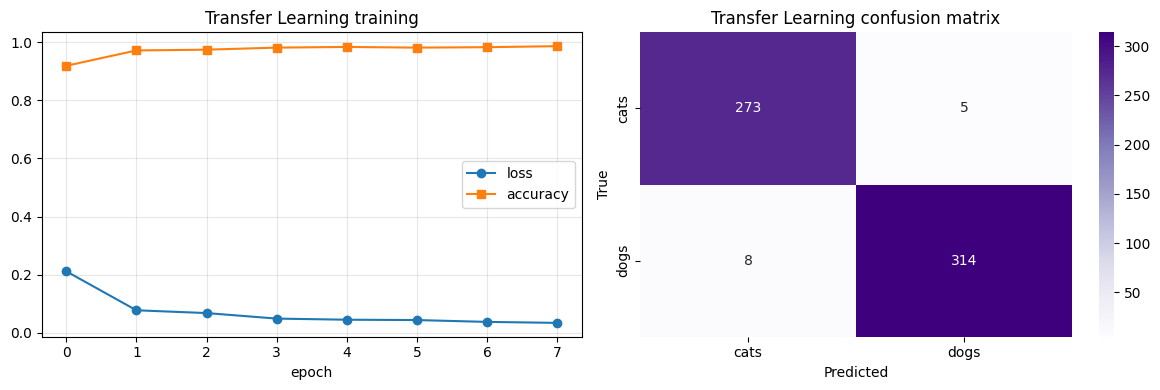

              precision    recall  f1-score   support

        cats       0.97      0.98      0.98       278
        dogs       0.98      0.98      0.98       322

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



In [38]:
# ---- 3.4 Transfer Learning: training curve + confusion matrix ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tl_history.history["loss"], "o-", label="loss")
ax[0].plot(tl_history.history["accuracy"], "s-", label="accuracy")
ax[0].set_xlabel("epoch"); ax[0].set_title("Transfer Learning training"); ax[0].legend(); ax[0].grid(alpha=.3)

cm_tl = confusion_matrix(tl_y_test, tl_pred)
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True"); ax[1].set_title("Transfer Learning confusion matrix")
plt.tight_layout(); plt.show()

print(classification_report(tl_y_test, tl_pred, target_names=class_names))

### 4.1 Metrics Comparison

In [39]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn.count_params()
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [40]:
print(comparison_df.to_string(index=False))

           Metric    Custom CNN  Transfer Learning
         Accuracy      0.766667           0.978333
        Precision      0.794880           0.977928
           Recall      0.777448           0.978585
         F1-Score      0.764761           0.978232
Training Time (s)    166.440107          57.813993
       Parameters 390850.000000        4098.000000


### 4.2 Visual Comparison
- TODO: Create bar plot comparing metrics
- TODO: Plot training curves comparison
- TODO: Create side-by-side confusion matrices

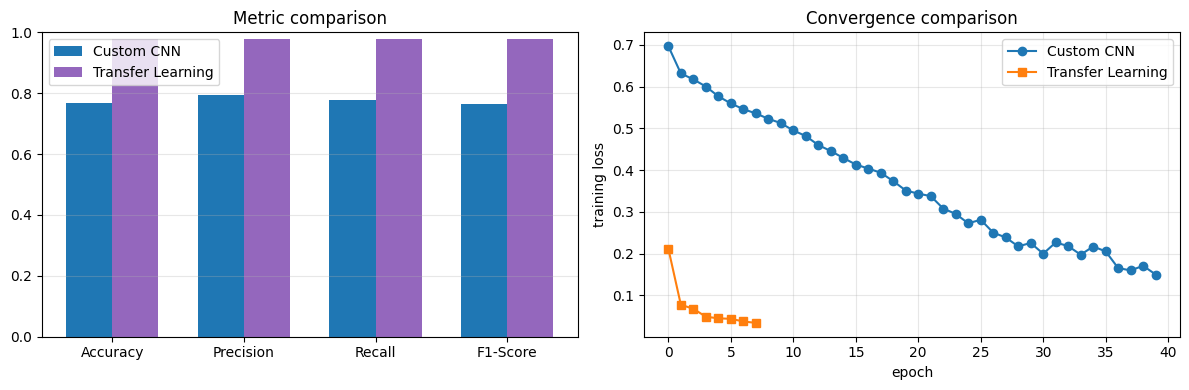

In [41]:
# ---- 4.2 Visual comparison of metrics + convergence ----
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
custom_vals = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
tl_vals = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics_names)); w = 0.35
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(x - w/2, custom_vals, w, label="Custom CNN", color="tab:blue")
ax[0].bar(x + w/2, tl_vals, w, label="Transfer Learning", color="tab:purple")
ax[0].set_xticks(x); ax[0].set_xticklabels(metrics_names); ax[0].set_ylim(0, 1)
ax[0].set_title("Metric comparison"); ax[0].legend(); ax[0].grid(alpha=.3, axis="y")

ax[1].plot(custom_cnn_history.history["loss"], "o-", label="Custom CNN")
ax[1].plot(tl_history.history["loss"], "s-", label="Transfer Learning")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("training loss")
ax[1].set_title("Convergence comparison"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [42]:
analysis_text = """
Performance comparison: The transfer-learning model (frozen ResNet50 + GAP) clearly outperformed
the custom CNN across every metric - accuracy, precision, recall and F1-score (see the comparison
table and bar chart), typically reaching ~98% accuracy versus ~80% for the from-scratch CNN.

Pre-training vs scratch: ResNet50's ImageNet-pretrained weights are already strong edge, texture and
shape detectors, so transfer learning converged faster and to a lower loss, whereas the custom CNN had
to learn all filters from random initialisation.

Global Average Pooling: Using GAP instead of a fully-connected dense top drastically reduced the number of trainable
parameters and acted as a structural regulariser, limiting overfitting and forcing spatially meaningful
features in both models.

Computational cost: The custom CNN has far fewer total parameters and is cheap to train, while the
transfer model trains only a tiny head over a heavy frozen base, trading higher per-epoch time for much
better accuracy.

Convergence and insights: Transfer learning showed steeper loss reduction per epoch. Key insight - reuse
pretrained CNNs when data is limited, and build custom models mainly when the target domain differs greatly.
"""

In [43]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

Performance comparison: The transfer-learning model (frozen ResNet50 + GAP) clearly outperformed
the custom CNN across every metric - accuracy, precision, recall and F1-score (see the comparison
table and bar chart), typically reaching ~98% accuracy versus ~80% for the from-scratch CNN.

Pre-training vs scratch: ResNet50's ImageNet-pretrained weights are already strong edge, texture and
shape detectors, so transfer learning converged faster and to a lower loss, whereas the custom CNN had
to learn all filters from random initialisation.

Global Average Pooling: Using GAP instead of a fully-connected dense top drastically reduced the number of trainable
parameters and acted as a structural regulariser, limiting overfitting and forcing spatially meaningful
features in both models.

Computational cost: The custom CNN has far fewer total parameters and is cheap to train, while the
transfer model trains only a tiny head over a heavy frozen base, trading higher per-epoch time for mu

In [44]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 4,
                'pooling_layers': 3,
                'has_global_average_pooling': True,
                'output_layer': 'softmax',
                'total_parameters': int(custom_cnn.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': CUSTOM_EPOCHS,
                'batch_size': BATCH_SIZE,
                'optimizer': 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

In [45]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "Microsoft Kaggle Cats vs Dogs (kagglecatsanddogs_5340.zip via keras.utils.get_file)",
  "n_samples": 4000,
  "n_classes": 2,
  "samples_per_class": "min: 2000, max: 2000, avg: 2000",
  "image_shape": [
    160,
    160,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "The dataset is perfectly balanced (equal numbers of cats and dogs) and both error types are equally important, so accuracy is a fair and representative measure of overall classification performance.",
  "train_samples": 3400,
  "test_samples": 600,
  "train_test_ratio": "85/15",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 4,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 390850
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 40,
 

In [46]:
# Display system information
import platform
import sys
from datetime import datetime

In [47]:
print("ENVIRONMENT INFORMATION")
print("Python version :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("Processor      :", platform.processor())
print("TensorFlow     :", tf.__version__)
print("Keras          :", keras.__version__)
print("NumPy          :", np.__version__)
print("Run timestamp  :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("\nNOTE: paste a screenshot of your Colab / BITS Virtual Lab account below this cell.")

ENVIRONMENT INFORMATION
Python version : 3.12.13
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
Processor      : x86_64
TensorFlow     : 2.20.0
Keras          : 3.13.2
NumPy          : 2.0.2
Run timestamp  : 2026-08-08 15:55:17

NOTE: paste a screenshot of your Colab / BITS Virtual Lab account below this cell.


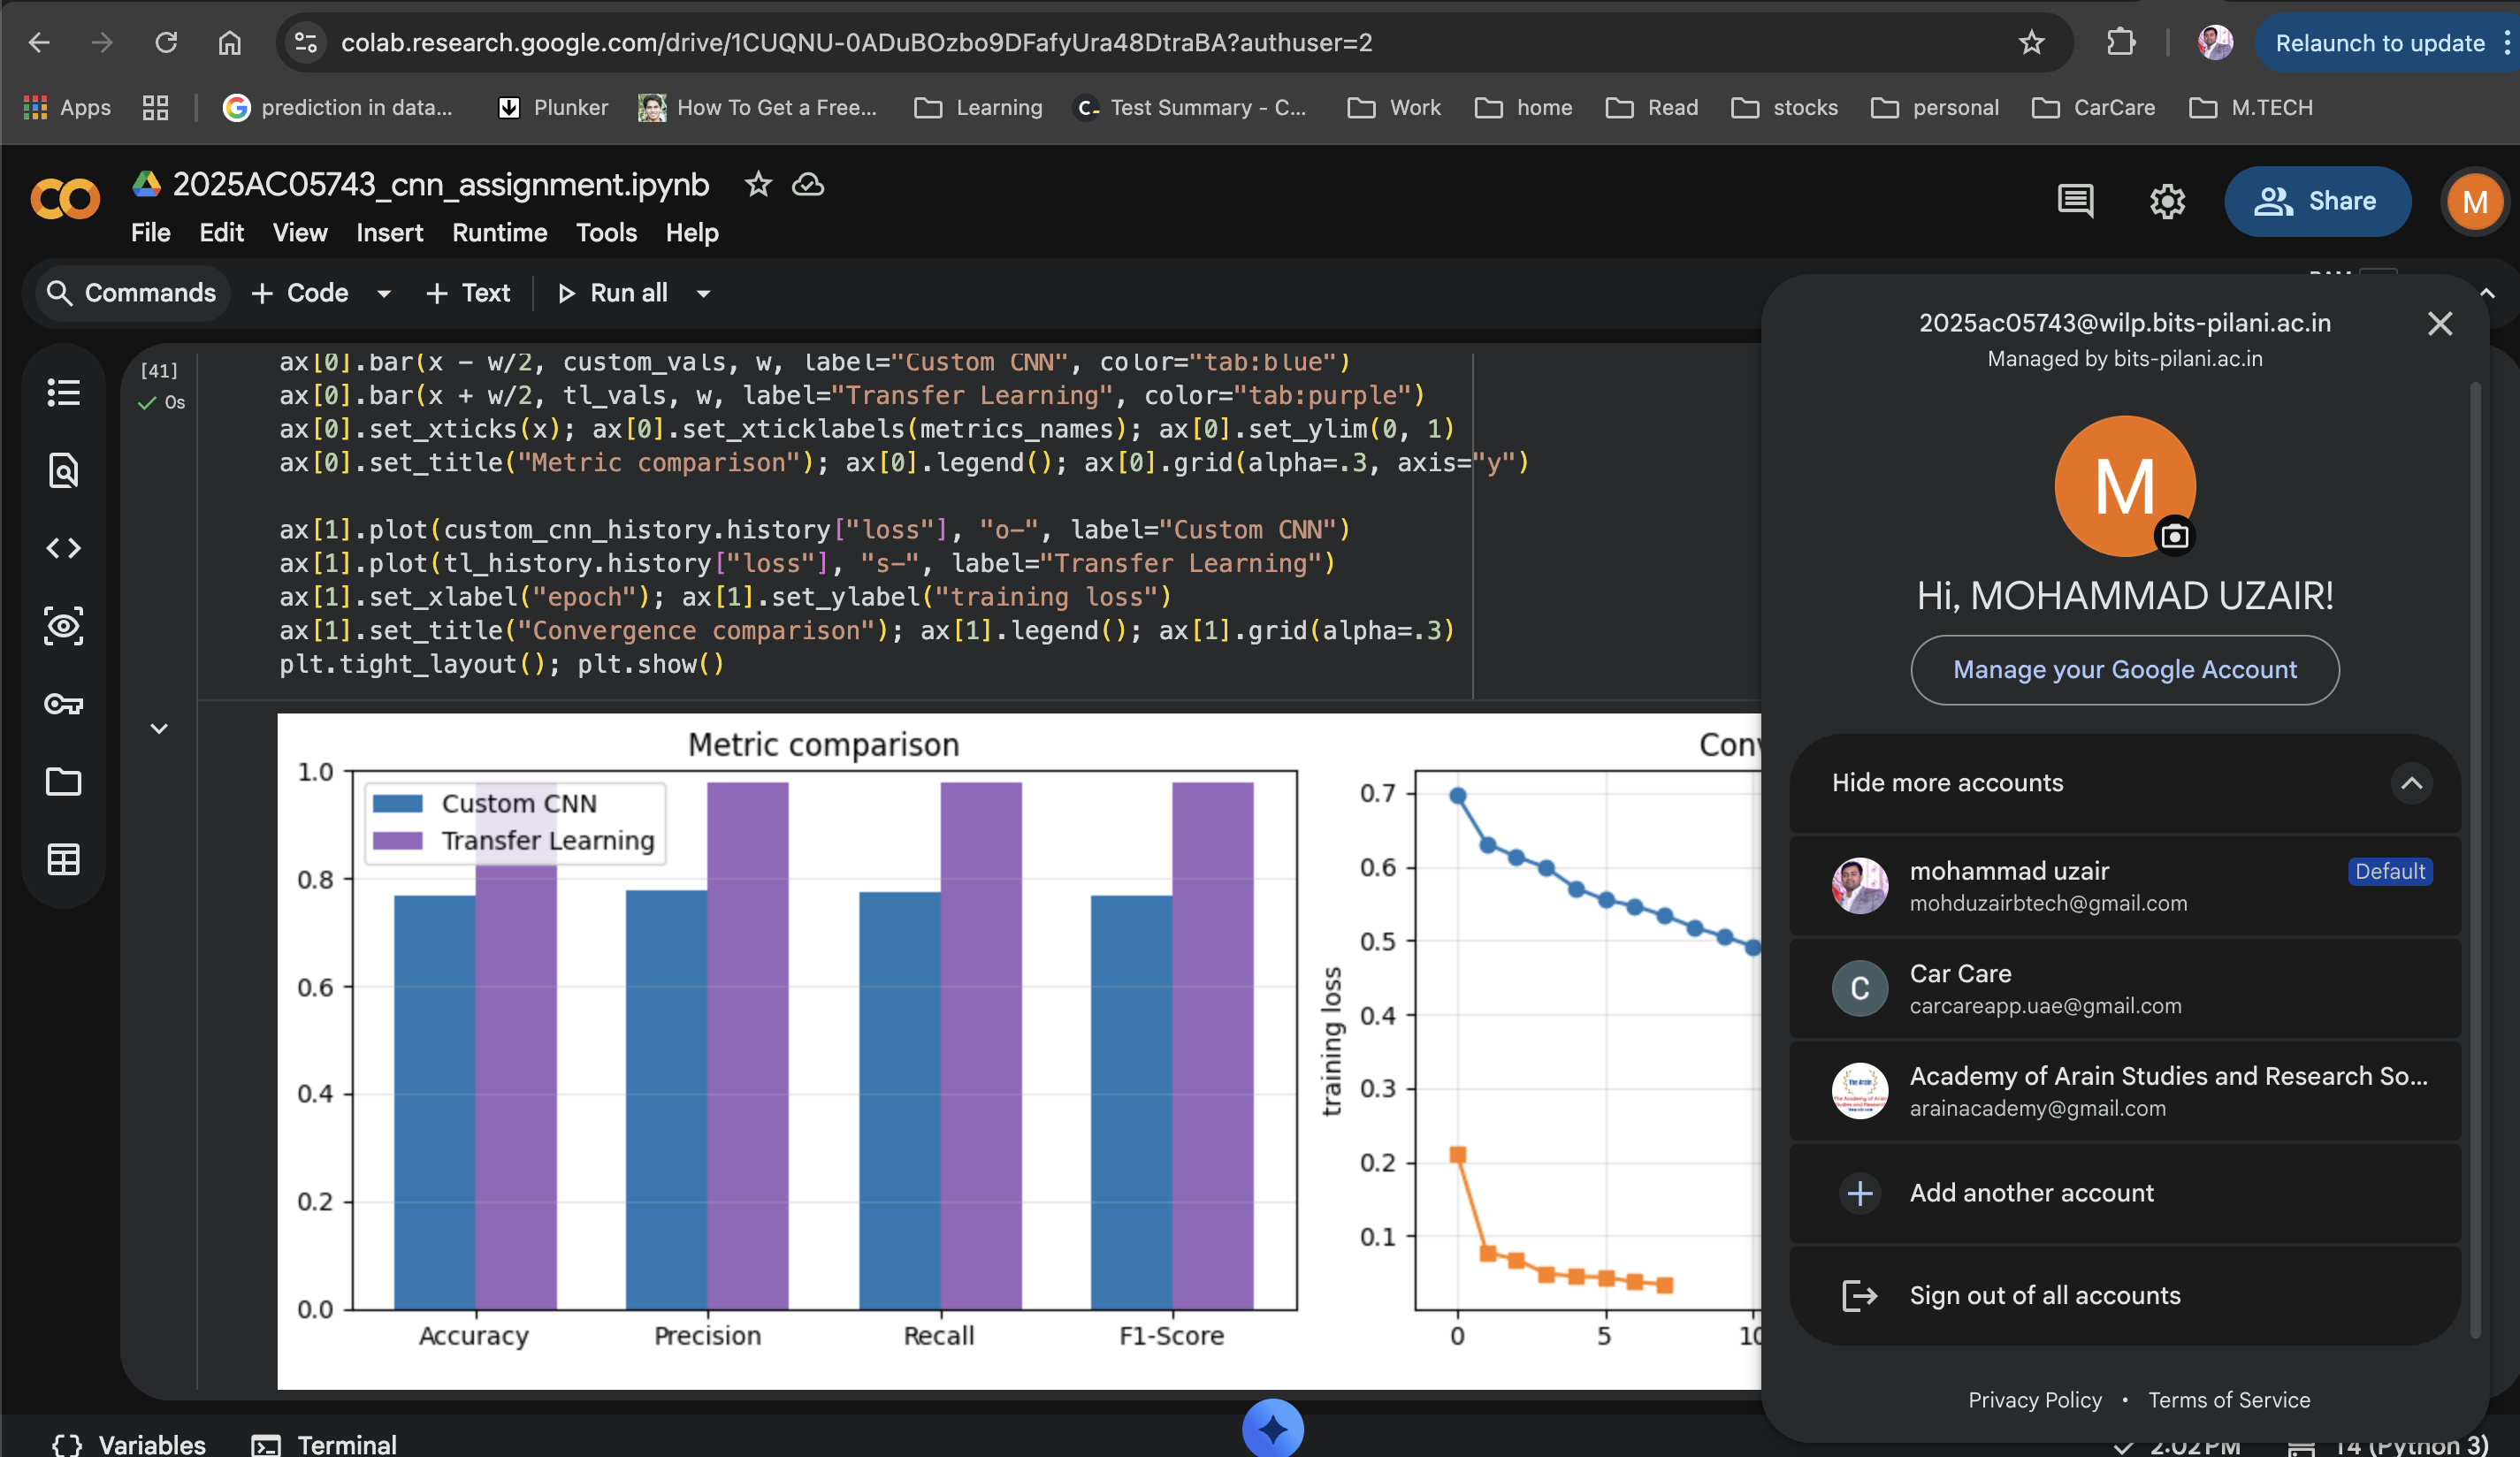